In [1]:
# calculation and plot
import numpy as np
import numpy.linalg as LA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# data processing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# predictor
import xgboost as xgb
from sklearn.model_selection import GridSearchCV


In [2]:
# train
df_train = pd.read_csv('../input/train.csv')
df_train['dataset'] = 'train'
# test
df_test = pd.read_csv('../input/test.csv')
df_test['dataset'] = 'test'
test_len = len(df_test)
# merge train and test
df = pd.concat([df_train, df_test], axis=0, ignore_index=True, sort=False)
df_len = len(df)


In [3]:
df.head()


,id,spacegroup,number_of_total_atoms,percent_atom_al,percent_atom_ga,percent_atom_in,lattice_vector_1_ang,lattice_vector_2_ang,lattice_vector_3_ang,lattice_angle_alpha_degree,lattice_angle_beta_degree,lattice_angle_gamma_degree,formation_energy_ev_natom,bandgap_energy_ev,dataset
0,1,206,80.0,0.3125,0.6250,0.0625,9.3282,9.3279,9.3277,90.0047,90.0045,89.9950,0.1337,2.6562,train
1,2,206,80.0,1.0000,0.0000,0.0000,8.9847,8.9839,8.9843,90.0024,90.0036,89.9994,0.0738,5.2114,train
2,3,227,40.0,0.8125,0.0000,0.1875,5.8341,5.8343,14.3401,89.9999,89.9980,120.0005,0.3671,1.8353,train
3,4,12,20.0,0.2500,0.6250,0.1250,12.3144,3.0840,5.9539,89.9999,104.1046,90.0001,0.0698,2.3056,train
4,5,33,80.0,0.0000,0.1875,0.8125,11.1457,9.4822,10.1054,89.9994,89.9967,90.0000,0.1154,0.9503,train


In [4]:
df.tail()


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,spacegroup,number_of_total_atoms,percent_atom_al,percent_atom_ga,percent_atom_in,lattice_vector_1_ang,lattice_vector_2_ang,lattice_vector_3_ang,lattice_angle_alpha_degree,lattice_angle_beta_degree,lattice_angle_gamma_degree,formation_energy_ev_natom,bandgap_energy_ev,dataset
2395,236,194,80.0,0.5000,0.5000,0.0000,6.2225,6.2224,23.7226,90.0187,89.9985,120.0009,NaN,NaN,test
2396,237,167,30.0,0.2500,0.5833,0.1667,5.0842,5.0838,13.6878,89.9968,90.0041,120.0005,NaN,NaN,test
2397,238,33,80.0,0.6562,0.2188,0.1250,10.0763,8.6437,9.2716,90.0034,90.0019,90.0012,NaN,NaN,test
2398,239,206,80.0,0.5625,0.4375,0.0000,9.1680,9.1675,9.1675,90.0042,90.0044,89.9963,NaN,NaN,test
2399,240,194,80.0,0.3750,0.3750,0.2500,6.4468,6.4466,24.1380,90.0128,90.0049,119.9952,NaN,NaN,test


In [5]:
def get_xyz(filename):    
    row = []
    xyz = []
    lattice = []
    
    with open(filename) as f:
        for line in f.readlines():
            row = line.split()
            if row[0] == 'atom':
                xyz.append((np.array(row[1:4], dtype=np.float), row[4]))
            elif row[0] == 'lattice_vector':
                lattice.append(np.array(row[1:4], dtype=np.float))
    
    return xyz, lattice


In [6]:
def get_sine_matrix(xyz, lattice):
    
    n_atom = len(xyz) # number of atoms in the cell
    
    distance_matrix = np.ones((n_atom, n_atom))
    A = np.transpose(lattice) # A = (a_1, a_2, a_3), defined as above
    B = LA.inv(A) # inverse matrix of A
    
    # matrix of distance
    for i in range(n_atom):
        for j in range(i):
            r_ij = np.dot(B, xyz[i][0] - xyz[j][0])
            sin_sq_r = (np.sin(np.pi * r_ij))**2
            distance = LA.norm(np.dot(A, sin_sq_r))
            distance_matrix[i, j], distance_matrix[j, i] = distance, distance
    # Note that diagonal components remain 1
    
    # matrix of charge by charge
    labels = np.transpose(xyz)[1] # element symbol labels
    labels = labels.reshape(-1,1)
    for at, charge in zip(['O', 'Al', 'Ga', 'In'], [8, 13, 31, 49]): # convert symbols into electric charges
        labels = np.where(labels==at, charge, labels)
    charge_matrix = np.dot(labels, np.transpose(labels)).astype(np.float)
    charge_matrix -= np.diag(np.diag(charge_matrix)) # let diagonal components zero
    charge_matrix += np.diag(0.5 * labels**2.4).astype(float) # from the definition
    
    # sine matrix
    sine_matrix = charge_matrix / distance_matrix
    
    return sine_matrix


In [7]:
def get_eigenspectrum(matrix):
    spectrum = LA.eigvalsh(matrix)
    spectrum = np.sort(spectrum)[::-1]
    
    return spectrum


In [8]:
spectrum_list = []

for index in range(df_len):
    
    dataset_label = df.dataset.values[index]
    row_id = df.id.values[index]
    filename = "../input/{}/{}/geometry.xyz".format(dataset_label, row_id)
    
    # file processing
    xyz, lattice = get_xyz(filename)
    # sine matrix
    sine_matrix = get_sine_matrix(xyz, lattice)
    # eigen spectrum
    spectrum = get_eigenspectrum(sine_matrix)
    
    spectrum_list.append(spectrum)


AttributeError: module 'numpy' has no attribute 'float'.
`np.float` was a deprecated alias for the builtin `float`. To avoid this error in existing code, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

IndexError: list index out of range

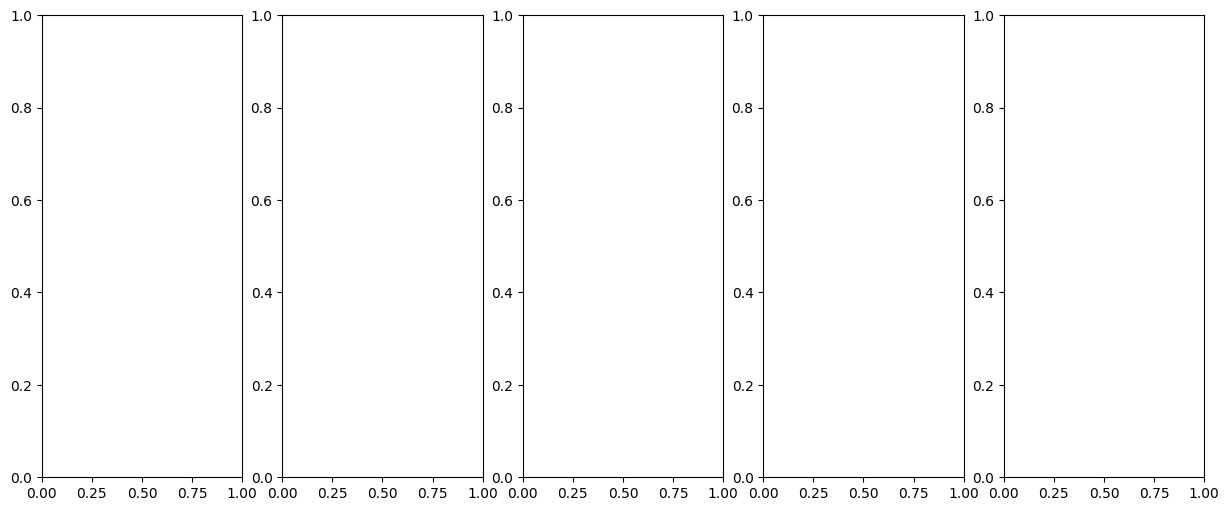

In [9]:
fig, axs = plt.subplots(1,5, figsize=(15, 6))
for i in range(5):
    ax = axs[i]
    plot_data = spectrum_list[i]
    ax.plot(range(len(plot_data)), plot_data)
    ax.hlines(0, 0, 80, colors='r')
plt.show()


In [10]:
spectrum_df = pd.DataFrame(spectrum_list).astype(np.float)
spectrum_df = spectrum_df.fillna(0)


AttributeError: module 'numpy' has no attribute 'float'.
`np.float` was a deprecated alias for the builtin `float`. To avoid this error in existing code, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

In [11]:
# standard scaling
ss = StandardScaler()
spectrum_std_df = pd.DataFrame(ss.fit_transform(spectrum_df.values))
# PCA
pca = PCA(n_components=80)
spectrum_pca_df = pd.DataFrame(pca.fit_transform(spectrum_std_df.values))

spectrum_pca_df.head()


NameError: name 'spectrum_df' is not defined

In [12]:
plt.scatter(x=spectrum_pca_df.loc[:100,0], y=spectrum_pca_df.loc[:100,1])
plt.show()


NameError: name 'spectrum_pca_df' is not defined

In [13]:
df.number_of_total_atoms = df.number_of_total_atoms.astype('int')
df['group_natoms'] = df.spacegroup.astype('str') + '_' + df.number_of_total_atoms.astype('str')


/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


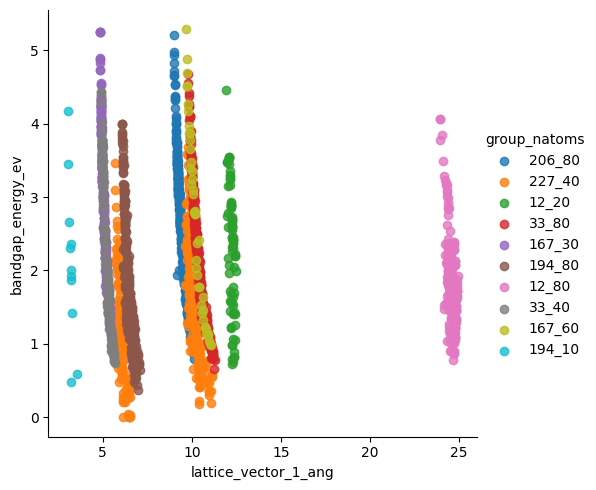

In [14]:
sns.lmplot(x='lattice_vector_1_ang', y='bandgap_energy_ev', hue='group_natoms', data=df, fit_reg=False)
plt.show()


In [15]:
df = df.join(pd.get_dummies(df.group_natoms))
df.drop(['group_natoms'], axis=1, inplace=True)


In [16]:
df.columns


Index(['id', 'spacegroup', 'number_of_total_atoms', 'percent_atom_al',
       'percent_atom_ga', 'percent_atom_in', 'lattice_vector_1_ang',
       'lattice_vector_2_ang', 'lattice_vector_3_ang',
       'lattice_angle_alpha_degree', 'lattice_angle_beta_degree',
       'lattice_angle_gamma_degree', 'formation_energy_ev_natom',
       'bandgap_energy_ev', 'dataset', '12_20', '12_80', '167_30', '167_60',
       '194_10', '194_80', '206_80', '227_40', '33_40', '33_80'],
      dtype='object')

In [17]:
df.drop(['dataset'], axis=1, inplace=True)
df.drop(['id', 'spacegroup', 'number_of_total_atoms'], axis=1, inplace=True)


In [18]:
df.columns


Index(['percent_atom_al', 'percent_atom_ga', 'percent_atom_in',
       'lattice_vector_1_ang', 'lattice_vector_2_ang', 'lattice_vector_3_ang',
       'lattice_angle_alpha_degree', 'lattice_angle_beta_degree',
       'lattice_angle_gamma_degree', 'formation_energy_ev_natom',
       'bandgap_energy_ev', '12_20', '12_80', '167_30', '167_60', '194_10',
       '194_80', '206_80', '227_40', '33_40', '33_80'],
      dtype='object')

In [19]:
df_new = pd.concat([spectrum_pca_df, df], axis=1)
df_new.head()


NameError: name 'spectrum_pca_df' is not defined

In [20]:
df_new.drop([395, 126, 1215, 1886, 2075, 353, 308, 2154, 531, 1379, 2319, 2337, 2370, 2333], axis=0, inplace=True)


NameError: name 'df_new' is not defined

In [21]:
df_new.shape


NameError: name 'df_new' is not defined

In [22]:
df_len = len(df_new)
train_len = df_len - test_len
# X
X_train = df_new.drop(['formation_energy_ev_natom', 'bandgap_energy_ev'], axis=1)[:train_len].values
X_test = df_new.drop(['formation_energy_ev_natom', 'bandgap_energy_ev'], axis=1)[train_len:].values
# y
y_formation = df_new['formation_energy_ev_natom'][:train_len].values
y_bandgap = df_new['bandgap_energy_ev'][:train_len].values


NameError: name 'df_new' is not defined

In [23]:
xgb_formation = xgb.XGBRegressor()
parameters = {
    'max_depth': [2, 3, 4],
    'n_estimators' : [100, 200, 300],
             }

cv_formation = GridSearchCV(xgb_formation, param_grid=parameters, cv=4, verbose=1)
cv_formation.fit(X_train, y_formation)


NameError: name 'X_train' is not defined

In [24]:
cv_formation.best_params_


AttributeError: 'GridSearchCV' object has no attribute 'best_params_'

In [25]:
xgb_bandgap = xgb.XGBRegressor()
parameters = {
    'max_depth': [2, 3, 4],
    'n_estimators' : [100, 200, 300],
             }

cv_bandgap = GridSearchCV(xgb_bandgap, param_grid=parameters, cv=4, verbose=1)
cv_bandgap.fit(X_train, y_bandgap)


NameError: name 'X_train' is not defined

In [26]:
cv_bandgap.best_params_


AttributeError: 'GridSearchCV' object has no attribute 'best_params_'

In [27]:
def plot_features(estimator, features):
    importances = estimator.feature_importances_
    plt.figure(figsize=(10, 15))
    plt.barh(range(len(importances)), importances , align='center')
    plt.yticks(np.arange(len(features)), features)
    plt.show()


In [28]:
features = df_new.drop(['formation_energy_ev_natom', 'bandgap_energy_ev'], axis=1).columns

plot_features(cv_formation.best_estimator_, features)
plot_features(cv_bandgap.best_estimator_, features)


NameError: name 'df_new' is not defined

In [29]:
formation_pred = cv_formation.predict(X_test)
bandgap_pred = cv_bandgap.predict(X_test)


NameError: name 'X_test' is not defined

In [30]:
submission = pd.DataFrame(np.arange(1, test_len + 1), columns=['id'])
submission['formation_energy_ev_natom'] = formation_pred
submission['bandgap_energy_ev'] = bandgap_pred
submission.shape


NameError: name 'formation_pred' is not defined

In [31]:
submission.head()


,id
0,1
1,2
2,3
3,4
4,5


In [32]:
submission.to_csv('submission.csv', index=False)
